# PINN exercises

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import torch
import torch.nn as nn

## Sheet 1

### 1.10a

Compare forward and backward Euler on $\frac{dx}{dt}=-\alpha x$.

In [2]:
# ====== Exponential ======
def forward_euler(f, x0, dt, T):
    x0 = np.atleast_1d(x0)
    ts = np.arange(0, T + dt, dt)
    xs = np.zeros((len(ts), len(x0)))
    xs[0] = x0

    for i in range(1, len(ts)):
        xs[i] = xs[i-1] + dt * f(xs[i-1], ts[i-1])
    
    return ts, xs

def backward_euler_alpha(alpha, x0, dt, T):
    """Backwards Euler for f(x,t)=-alpha*x"""
    x0 = np.atleast_1d(x0)
    ts = np.arange(0, T + dt, dt)
    xs = np.zeros((len(ts), len(x0)))
    xs[0] = x0
    for i in range(1, len(ts)):
        xs[i] = xs[i-1] / (1 + alpha * dt)
    return ts, xs

In [5]:
def exact(t, alpha, x0=1.0):
    return x0 * np.exp(-alpha * t)

def linear_rhs(x, t, alpha):
    return -alpha * x

T = 5.0
x0 = 1.0

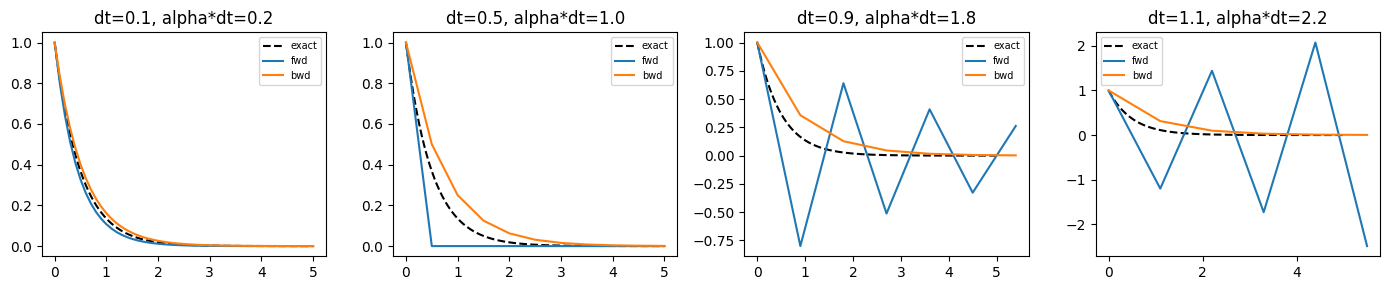

In [6]:
# --- experiment 1: vary dt for fixed alpha ---
# forward euler goes unstable when dt > 2/alpha
alpha = 2.0
dts = [0.1, 0.5, 0.9, 1.1]  # straddle the dt=1 stability boundary

fig, axes = plt.subplots(1, len(dts), figsize=(14, 3))
for ax, dt in zip(axes, dts):
    ts, xs = forward_euler(lambda x, t: linear_rhs(x, t, alpha), x0, dt, T)
    ts_b, xs_b = backward_euler_alpha(alpha, x0, dt, T)
    t_fine = np.linspace(0, T, 300)
    ax.plot(t_fine, exact(t_fine, alpha), 'k--', label='exact')
    ax.plot(ts, xs[:, 0], label='fwd')
    ax.plot(ts_b, xs_b, label='bwd')
    ax.set_title(f'dt={dt}, alpha*dt={alpha*dt:.1f}')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

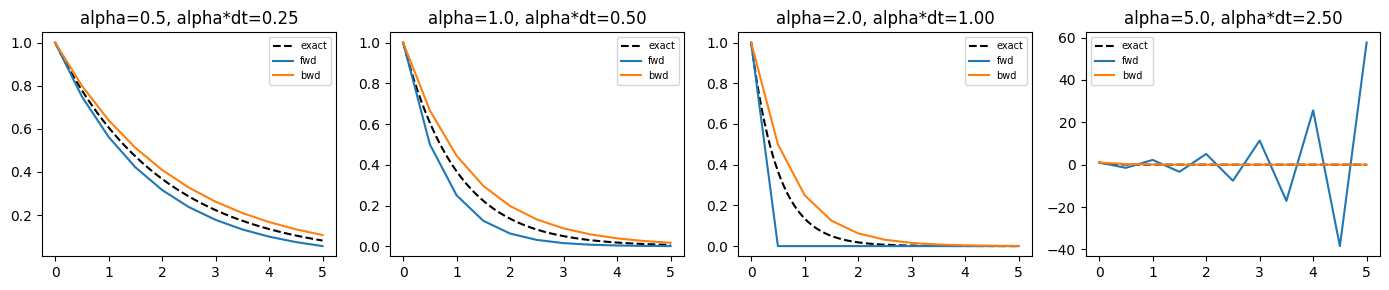

In [7]:
# --- experiment 2: vary alpha for fixed dt ---
dt = 0.5
alphas = [0.5, 1.0, 2.0, 5.0]  # alpha*dt = 0.25, 0.5, 1.0, 2.5

fig, axes = plt.subplots(1, len(alphas), figsize=(14, 3))
for ax, alpha in zip(axes, alphas):
    ts, xs = forward_euler(lambda x, t: linear_rhs(x, t, alpha), x0, dt, T)
    ts_b, xs_b = backward_euler_alpha(alpha, x0, dt, T)
    t_fine = np.linspace(0, T, 300)
    ax.plot(t_fine, exact(t_fine, alpha), 'k--', label='exact')
    ax.plot(ts, xs[:, 0], label='fwd')
    ax.plot(ts_b, xs_b, label='bwd')
    ax.set_title(f'alpha={alpha}, alpha*dt={alpha*dt:.2f}')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

### 1.10b

Simulate the Lotka-Volterra equations.

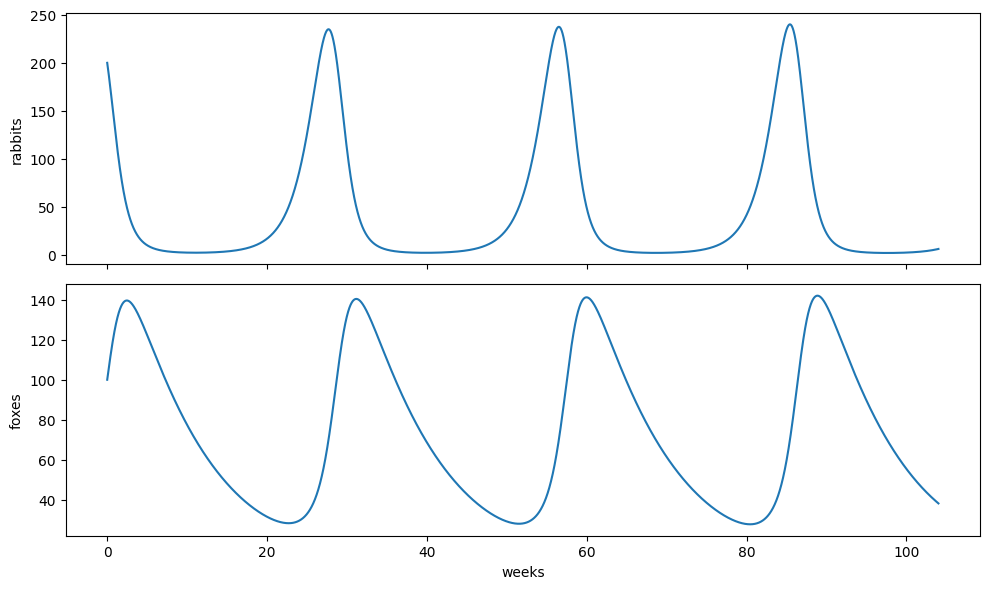

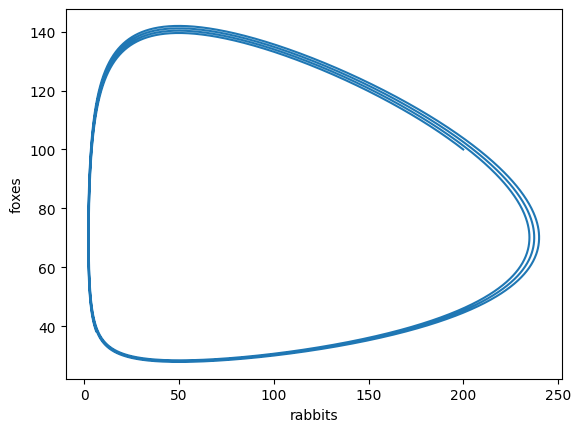

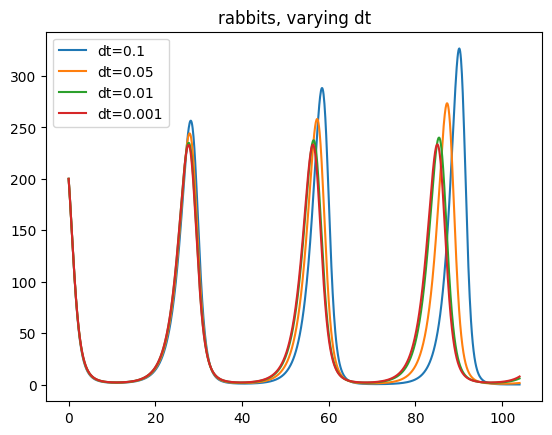

In [8]:
def lv_rhs(y, t, alpha=0.7, beta=0.01, gamma=0.1, delta=0.002):
    R, F = y
    return np.array([
        alpha*R - beta*R*F,
        -gamma*F + delta*R*F
    ])

# run
y0 = np.array([200.0, 100.0])
T = 104.0  # 2 years in weeks
ts, ys = forward_euler(lv_rhs, y0, dt=0.01, T=T)

# plot populations over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(ts, ys[:, 0], label='rabbits')
ax2.plot(ts, ys[:, 1], label='foxes')
ax1.set_ylabel('rabbits'); ax2.set_ylabel('foxes'); ax2.set_xlabel('weeks')
plt.tight_layout()
plt.show()

# phase portrait
plt.plot(ys[:, 0], ys[:, 1])
plt.xlabel('rabbits'); plt.ylabel('foxes')
plt.show()

# vary dt to show instability
for dt in [0.1, 0.05, 0.01, 0.001]:
    ts, ys = forward_euler(lv_rhs, y0, dt=dt, T=T)
    plt.plot(ts, ys[:, 0], label=f'dt={dt}')
plt.legend(); plt.title('rabbits, varying dt'); plt.show()

## Sheet 2

### 2.6a

Collocation of basic functions with low-degree polynomials.



/var/folders/7_/dyzyr7j12mx5_8rbvq0b52r80000gn/T/ipykernel_23974/2582455687.py:12: RuntimeWarning: divide by zero encountered in divide
  r'$1/(1-x^2)$':   1 / (1 - x_plot**2),


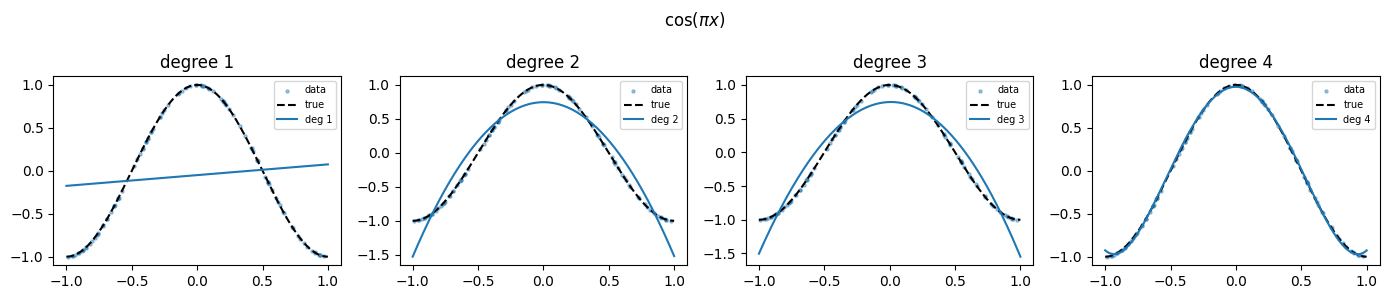

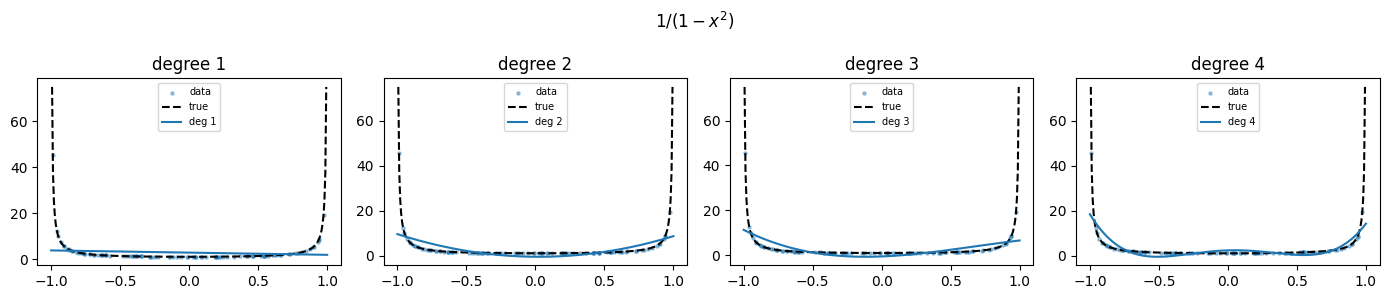

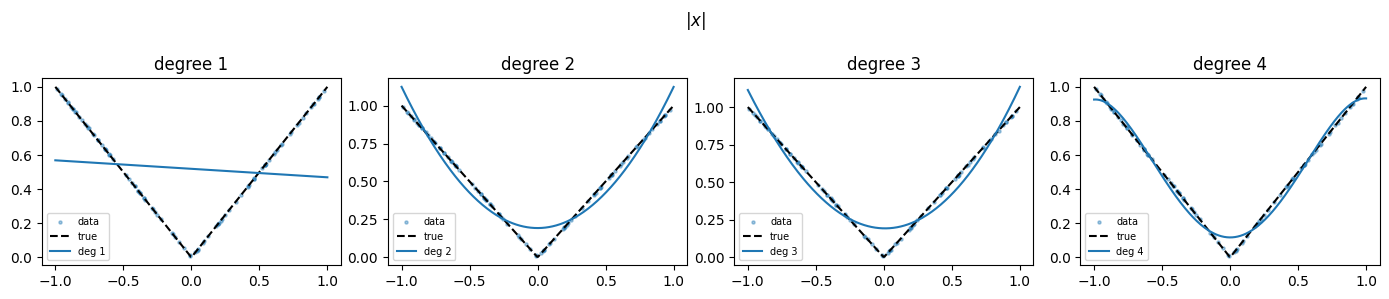

In [9]:
np.random.seed(42)
x = np.random.uniform(-1, 1, 100)
x_plot = np.linspace(-1, 1, 300)

functions = {
    r'$\cos(\pi x)$': np.cos(np.pi * x),
    r'$1/(1-x^2)$':   1 / (1 - x**2),
    r'$|x|$':         np.abs(x),
}
functions_plot = {
    r'$\cos(\pi x)$': np.cos(np.pi * x_plot),
    r'$1/(1-x^2)$':   1 / (1 - x_plot**2),
    r'$|x|$':         np.abs(x_plot),
}

degrees = [1, 2, 3, 4]

for fname, y in functions.items():
    fig, axes = plt.subplots(1, 4, figsize=(14, 3))
    fig.suptitle(fname)
    for ax, deg in zip(axes, degrees):
        coeffs = np.polyfit(x, y, deg)
        y_fit = np.polyval(coeffs, x_plot)
        ax.scatter(x, y, s=5, alpha=0.4, label='data')
        ax.plot(x_plot, functions_plot[fname], 'k--', label='true')
        ax.plot(x_plot, y_fit, label=f'deg {deg}')
        ax.set_title(f'degree {deg}')
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

### 2.6b

Euler method for $y''=10xy$.

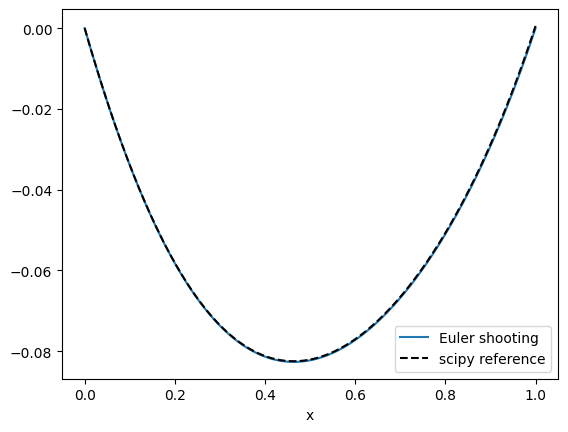

In [13]:
def bvp_rhs_u(y, t):
    # u'' = 10xu + 1, u(0)=0, u'(0)=0
    return np.array([y[1], 10*t*y[0] + 1])

def bvp_rhs_v(y, t):
    # v'' = 10xv, v(0)=0, v'(0)=1
    return np.array([y[1], 10*t*y[0]])

dt = 0.001
T = 1.0

_, u = forward_euler(bvp_rhs_u, np.array([0.0, 0.0]), dt, T)
_, v = forward_euler(bvp_rhs_v, np.array([0.0, 1.0]), dt, T)

# y = u + (0 - u(1))/v(1) * v
c = -u[-1, 0] / v[-1, 0]
ts = np.arange(0, T + dt, dt)
y_sol = u[:, 0] + c * v[:, 0]

sol = solve_ivp(lambda t, y: bvp_rhs_u(y, t), [0, 1], [0, 0], dense_output=True, max_step=0.001)
# this isn't the BVP solution, it's just u -- need the full shooting combination

x_plot = np.linspace(0, 1, 300)
y_ref = sol.sol(x_plot)[0] + c * solve_ivp(
    lambda t, y: bvp_rhs_v(y, t), [0, 1], [0, 1], dense_output=True, max_step=0.001
).sol(x_plot)[0]

plt.plot(ts, y_sol, label='Euler shooting')
plt.plot(x_plot, y_ref, 'k--', label='scipy reference')
plt.xlabel('x'); plt.legend(); plt.show()

### 2.6c

Finite difference errors for simple BVP

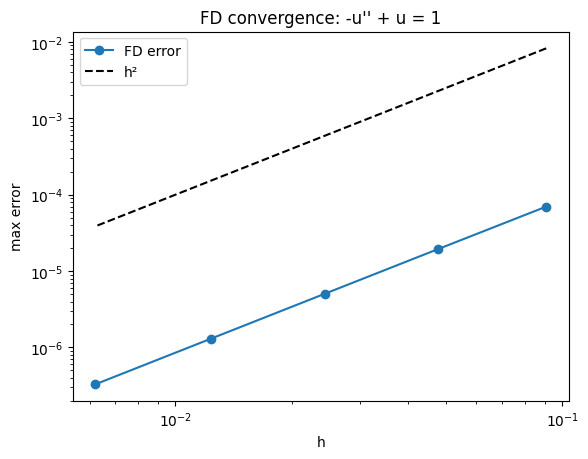

In [14]:
def true_solution(x):
    return 1 - (np.exp(x) + np.exp(1 - x)) / (np.exp(1) + 1)

def fd_solve(n):
    h = 1.0 / (n + 1)
    x = np.linspace(h, 1 - h, n)
    # -(u_{i-1} - 2u_i + u_{i+1})/h^2 + u_i = 1
    diag = 2/h**2 + 1
    off  = -1/h**2
    A = np.diag([diag]*n) + np.diag([off]*(n-1), 1) + np.diag([off]*(n-1), -1)
    b = np.ones(n)
    u = np.linalg.solve(A, b)
    err = np.max(np.abs(u - true_solution(x)))
    return h, err

ns = [10, 20, 40, 80, 160]
hs, errs = zip(*[fd_solve(n) for n in ns])

plt.loglog(hs, errs, 'o-', label='FD error')
plt.loglog(hs, [h**2 for h in hs], 'k--', label='h²')
plt.xlabel('h'); plt.ylabel('max error'); plt.legend()
plt.title('FD convergence: -u\'\' + u = 1')
plt.show()

## Sheet 3

## 3.7a

Approximating $e^x$ via collocation

/var/folders/7_/dyzyr7j12mx5_8rbvq0b52r80000gn/T/ipykernel_23974/4035489937.py:15: RuntimeWarning: divide by zero encountered in reciprocal
  A[:, j] = j * x**(j-1) - x**j  # phi_j' - phi_j
/var/folders/7_/dyzyr7j12mx5_8rbvq0b52r80000gn/T/ipykernel_23974/4035489937.py:15: RuntimeWarning: invalid value encountered in multiply
  A[:, j] = j * x**(j-1) - x**j  # phi_j' - phi_j


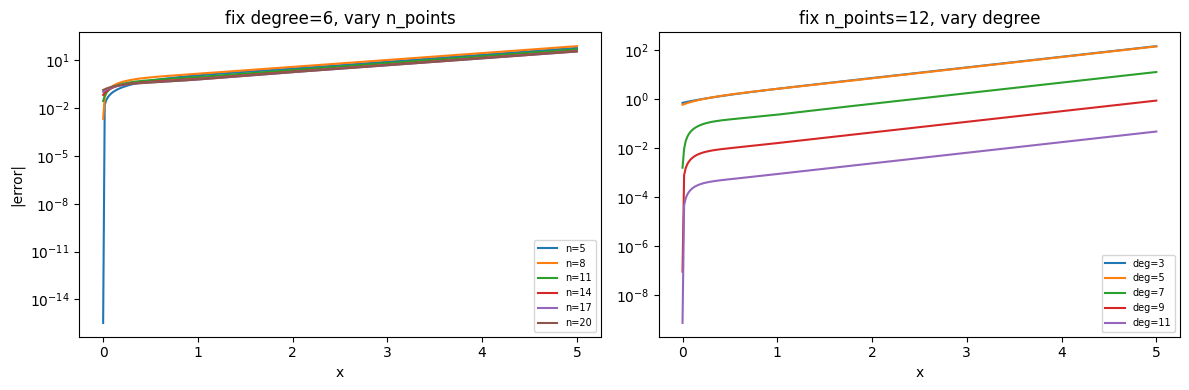

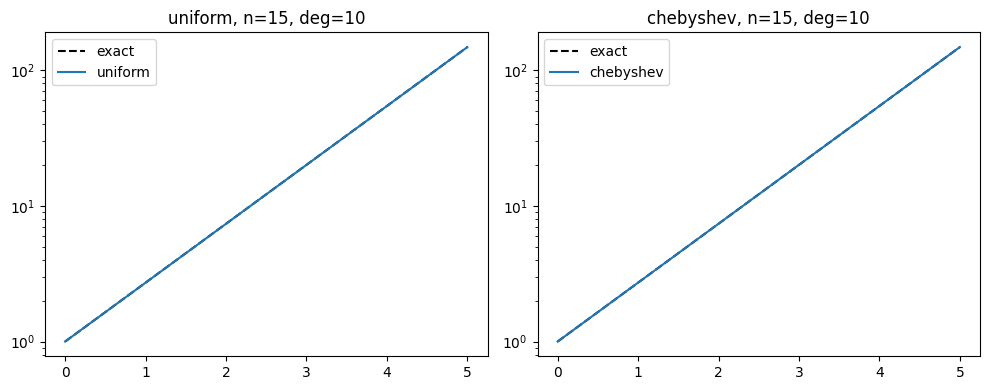

In [17]:
# ============ Q7a: Polynomial Collocation on y' - y = 0 ============

def poly_collocation(n_points, degree, distribution='uniform'):
    if distribution == 'uniform':
        x = np.linspace(0, 5, n_points)
    else:  # chebyshev
        k = np.arange(1, n_points + 1)
        x = 2.5 + 2.5 * np.cos((2*k - 1) * np.pi / (2*n_points))
    
    # basis: phi_j(x) = x^j, phi_j'(x) = j*x^(j-1)
    # residual: y' - y = 0 at collocation points
    # y(0) = 1 as extra condition -> replace first row
    A = np.zeros((n_points, degree + 1))
    for j in range(degree + 1):
        A[:, j] = j * x**(j-1) - x**j  # phi_j' - phi_j
    
    b = np.zeros(n_points)
    # enforce y(0) = 1 via first row
    A[0, :] = np.array([0**j for j in range(degree + 1)])
    b[0] = 1.0
    
    coeffs, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    
    x_plot = np.linspace(0, 5, 300)
    y_approx = np.polyval(coeffs[::-1], x_plot)
    return x_plot, y_approx

x_plot = np.linspace(0, 5, 300)
exact = np.exp(x_plot)

# --- experiment 1: fix degree, vary n_points ---
degree = 6
n_points_list = [5, 8, 11, 14, 17, 20]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for n in n_points_list:
    _, yp = poly_collocation(n, degree, 'uniform')
    axes[0].semilogy(x_plot, np.abs(yp - exact), label=f'n={n}')
axes[0].set_title(f'fix degree={degree}, vary n_points')
axes[0].legend(fontsize=7); axes[0].set_xlabel('x'); axes[0].set_ylabel('|error|')

# --- experiment 2: fix n_points, vary degree ---
n_points = 12
degrees = [3, 5, 7, 9, 11]

for d in degrees:
    _, yp = poly_collocation(n_points, d, 'uniform')
    axes[1].semilogy(x_plot, np.abs(yp - exact), label=f'deg={d}')
axes[1].set_title(f'fix n_points={n_points}, vary degree')
axes[1].legend(fontsize=7); axes[1].set_xlabel('x')
plt.tight_layout(); plt.show()

# --- experiment 3: fix n_points and degree, vary distribution ---
n_points, degree = 15, 10
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for dist, ax in zip(['uniform', 'chebyshev'], axes):
    _, yp = poly_collocation(n_points, degree, dist)
    ax.plot(x_plot, exact, 'k--', label='exact')
    ax.plot(x_plot, yp, label=dist)
    ax.semilogy() 
    ax.set_title(f'{dist}, n={n_points}, deg={degree}')
    ax.legend()
plt.tight_layout(); plt.show()

### 3.7b

Approximation with NN

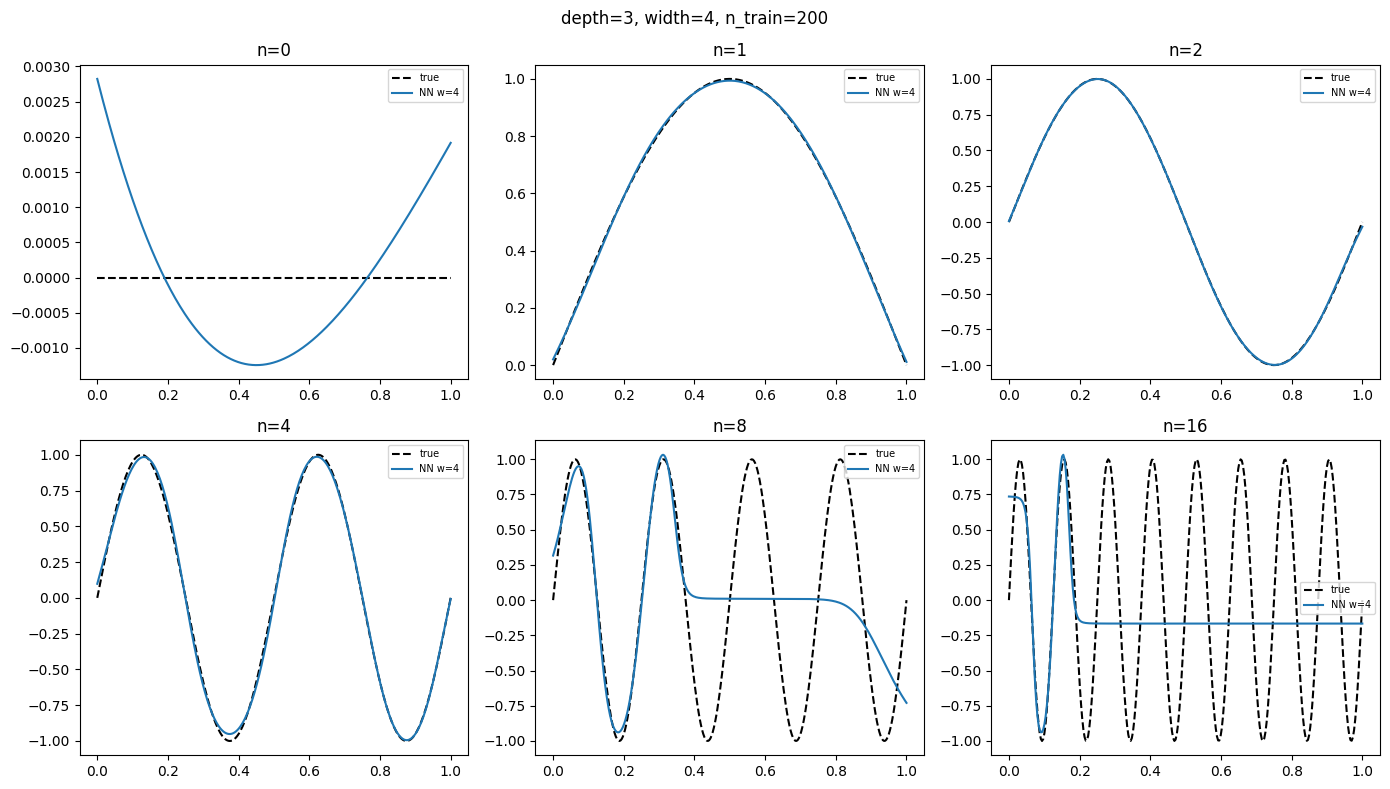

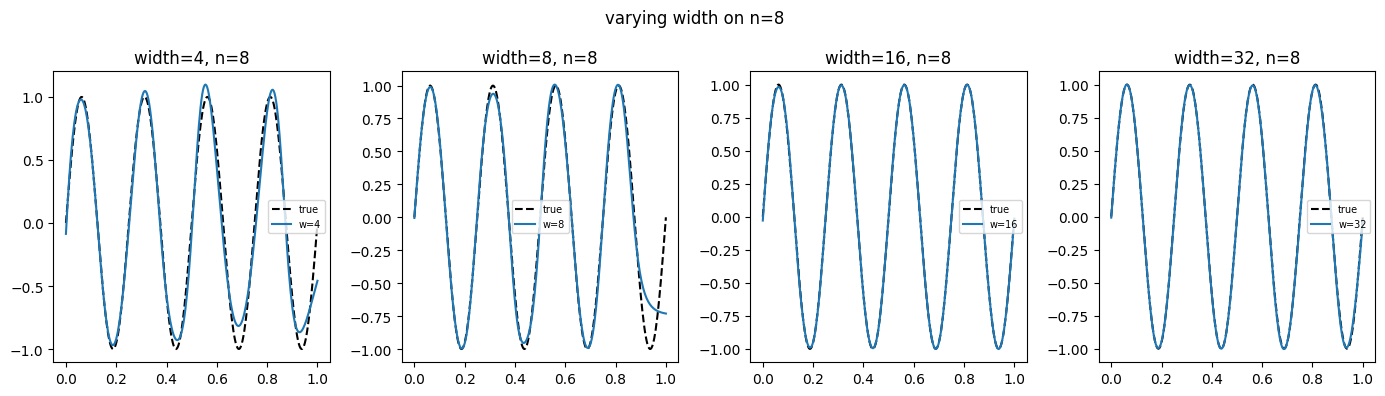

In [18]:
# ============ Q7b: NN fitting sin(n*pi*x) ============

class MLP(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, width), nn.Tanh(),
            nn.Linear(width, width), nn.Tanh(),
            nn.Linear(width, width), nn.Tanh(),
            nn.Linear(width, 1)
        )
    def forward(self, x):
        return self.net(x)

def train_nn(n_freq, n_train, width=4, n_epochs=5000):
    x = torch.rand(n_train, 1)
    y = torch.sin(n_freq * torch.pi * x)
    model = MLP(width)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for _ in range(n_epochs):
        opt.zero_grad()
        loss = ((model(x) - y)**2).mean()
        loss.backward()
        opt.step()
    return model

freqs = [0, 1, 2, 4, 8, 16]
n_train = 200
x_plot = torch.linspace(0, 1, 300).unsqueeze(1)

# vary frequency, fixed width=4
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, n in zip(axes.flat, freqs):
    model = train_nn(n, n_train, width=4)
    with torch.no_grad():
        y_pred = model(x_plot).numpy()
    ax.plot(x_plot.numpy(), np.sin(n * np.pi * x_plot.numpy()), 'k--', label='true')
    ax.plot(x_plot.numpy(), y_pred, label='NN w=4')
    ax.set_title(f'n={n}'); ax.legend(fontsize=7)
plt.suptitle('depth=3, width=4, n_train=200'); plt.tight_layout(); plt.show()

# vary width for high frequency
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, w in zip(axes, [4, 8, 16, 32]):
    model = train_nn(8, n_train, width=w)
    with torch.no_grad():
        y_pred = model(x_plot).numpy()
    ax.plot(x_plot.numpy(), np.sin(8 * np.pi * x_plot.numpy()), 'k--', label='true')
    ax.plot(x_plot.numpy(), y_pred, label=f'w={w}')
    ax.set_title(f'width={w}, n=8'); ax.legend(fontsize=7)
plt.suptitle('varying width on n=8'); plt.tight_layout(); plt.show()